# defer 延迟执行

1. 之前演示过几个节点并行执行，并行执行的时候，几个节点是同时执行的，节约大模型回复的时间
2. 但是有时候 我们希望有的节点拖到最后进行工作， 需要等待所有的内容执行完， 这个时候可以使用defer， 延时执行内容
3. 操作：添加节点的时候，设置defer=True，通常用于日志，审计等收尾工作，比较特别，被特殊打标记了，所以所有运行流程结束了， 额外的超步执行
    1. 还有一个节点，可以读取到其他节点相关，更新的状态，拿到的是最后的结果数据

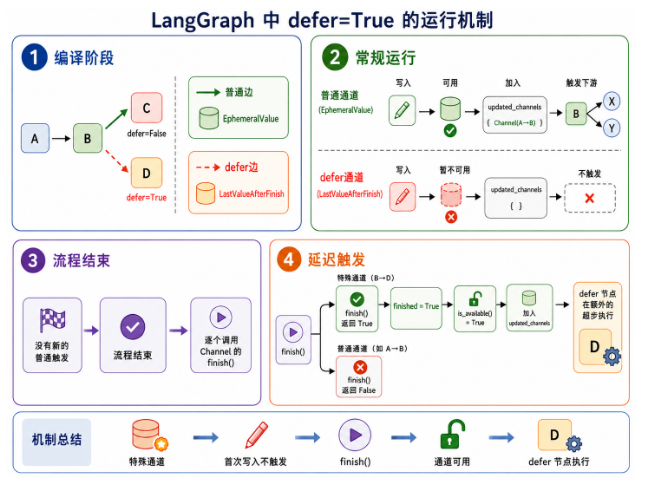

看上面langgraph底层的代码是怎么实现的
1. 首先记录的是很好，会找到特殊的节点defer，延时节点，记录下来是一个延时的边，然后单独标记
2. 下面进行运行，没有标记延时的通道都会正常运行，superstep正常， defer被执行节点的时候，会指向，但是不会出发运行
3. 等常规所有流程执行完毕后（图结束了）
4. 会有finish事件， 会有finish的标记，会打开延时defer节点的锁，让延时节点在额外的超步中去执行，出发解锁逻辑，让延时节点在额外的superstep中执行

使用额外的特殊通道，首次不触发， 后面触发

底层原理：
1. 编译阶段， 创建不同的Channel，普通节点是EmphemeralValue， 特殊的是lastValueAfterFinish
2. 常规阶段，写入但不触发
3. 常规流程结束后，finish()唤醒延迟节点

整个逻辑如上，再看案例

2026-09-09 14:45:03.193 | INFO     | __main__:audit_node:41 - 任务节点已经全部执行完毕，诗已生成，笑话已生成


{'topic': '猫咪', 'poem': '## 《猫》\n\n它善于在暗处移行，并让好奇\n保持弓形的警惕\n它绿松石的目光，常常洞穿\n午后倾斜的光线，捕捉\n\n绒线球里的王国\n而窗台垂落的尾巴，正试图\n丈量蝴蝶翼上的\n季风涡旋\n\n那些陶罐状的睡眠\n蜷成螺旋，盛满呼噜的嗡鸣\n在它腹部的起伏里，黄昏正被\n舐成靛蓝的墨水\n\n忽然，铃铛撞响空气的\n银纹——它跃过琴键时\n尾尖的弧线\n泄露了月光\n古老而轻盈的韵脚', 'joke': '猫咪走进咖啡馆，对服务员说：“来杯鱼香拿铁。”\n\n服务员愣了一下：“我们这儿没有鱼香拿铁啊。”\n\n猫咪叹了口气：“那来份猫粮蛋糕吧。”\n\n服务员又摇头：“也没有猫粮蛋糕……您看，我们这儿是给人准备的菜单。”\n\n猫咪失望地喵了一声，转身要走，又回头说：“那至少给我一碟牛奶吧，不加糖——唉，毕竟你们人类连个像样的猫零食都不准备。”\n\n服务员一边倒牛奶一边嘀咕：“这猫怎么这么讲究……”\n\n猫咪耳朵一竖，回头瞪他：“讲究？我连毛都舔干净了才进来的，你闻闻，是不是还带薄荷味？”\n\n服务员凑近闻了闻，差点被猫薄荷味儿熏晕，咳嗽着说：“得嘞，您这还自带提神功能。”\n\n猫咪优雅地舔了口牛奶，慢悠悠地说：“那是——我们猫界规矩：进咖啡馆，先熏人，再熏猫，这叫入乡随俗。”\n\n服务员笑喷了：“您这懂的可真多。”\n\n猫咪眯起眼睛：“不懂？我连你昨天几点在网上搜‘怎么让猫高兴’都知道——查完还改了八遍购物车，最后买了只逗猫棒，结果自己玩了一晚上。”\n\n服务员脸一红：“您怎么知道的……”\n\n猫咪把空碟子一推，跳下椅子：“因为那逗猫棒是我推荐的，回头客好评哦——走了，下次记得进点鱼香拿铁，不然我就去隔壁狗餐厅投诉你歧视猫客。”\n\n服务员对着它的背影喊：“那您倒是常来啊！”\n\n猫咪头也不回：“放心，我每天来监督你们人类的咖啡质量——顺便蹭点免费的薄荷牛奶。”\n\n从此，这家咖啡馆多了条规矩：进门的猫必须自带猫薄荷，否则不让听八卦。'}


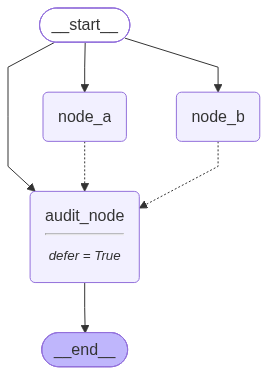

In [2]:
# 例子，先写使用path_map，等下再写不写path_map

from dotenv import load_dotenv
load_dotenv(override=True) # 如果有其他名称， 去覆盖
from langchain_deepseek import ChatDeepSeek
from typing import TypedDict,Annotated,Literal
from langgraph.graph import StateGraph,START,END
from loguru import logger
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

# 2. 定义节点
def node_a(state:OverAllState) -> OverAllState:
    poem = model.invoke(f"写一首关于{state['topic']}主题的诗").content
    return {
        "poem": poem
    }

def node_b(state:OverAllState) -> OverAllState:
    joke = model.invoke(f"写一个关于{state['topic']}的笑话").content
    return {
        "joke": joke
    }

def audit_node(state: OverAllState) -> OverAllState:
    logger.info(f"任务节点已经全部执行完毕，诗{'已生成' if state['poem'] else '未生成'}，笑话{'已生成' if state['joke'] else '未生成'}")


# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("audit_node", audit_node, defer=True) # 加了延时， 最后执行， 如果没执行，打印的都是未完成

builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge(START, "audit_node") # 三个一起运行

builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("audit_node", END)


graph = builder.compile()
poem_res = graph.invoke({"topic":"猫咪"})
print(poem_res)


display(graph) # 图最后显示是延迟执行，虽然start直接连着audit_node，但是不会真正运行，只有全部执行完了才会执行，才能拿到别人的数据， 一般节点拿不到别人的数据
